# Section 7

## Certification weight: 10%

## Objectives
- Retrieve previous experiment results (session/Qiskit Runtime)
- Monitor jobs

A job is an instance of a circuit executed on a backend (simulator or real quantum computer)

Two kinds of jobs objects are created, depending the backend
- PrimitiveJob (created by BackendPrimitives) are typically jobs ran locally
- RuntimeJob 

Each job contains medatadata (job duration, date, ....) and the results

When the job is running, the job object's method `cancel()` will cancel the job
When the job is running, or once it's done, some methods can be used to interact with the job:
- job.job_id() : get the job identifier
- job.result() : get the result (get a `PrimitiveResult`object)
- job.status() : get the status (eg: JobStatus.DONE, JobStatus.RUNNING)


Other methods are avaiable to interact with jobs, or to get their status and info:
- job.in_final_state() / job.wait_for_final_state(timeout=None): tells if a job is in final state (won't evoles) such as DONE, ERROR, or CANCELLED ; or waits to reach a final state
- job.done() / job.cancelled(): return `True` if the jobs finished without error ; or if it had been cancelled by the user


When executed on a IBM Quantum computer, those methods can be called:
- job.backend() : get the backend where the job run
- job.metrics(): get the timestamp and duration (QPU time) of the job
- job.logs(): get the logs, only available when the job is finished
- job.errored() / job.error_message(): return `True` if the job finished with an error; and get the error message (return `None` if no error message)
- job.update_tags([string]): assign this tag list to a job



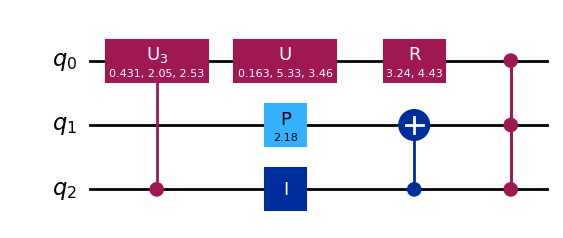

In [1]:
from qiskit.circuit.random import random_circuit
from qiskit import QuantumCircuit
from qiskit_ibm_runtime.sampler import SamplerV2

qc = QuantumCircuit(3)
qc = random_circuit(3, 5)
qc.draw("mpl")

In [7]:
qc.measure_all()

from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit import transpile

backend = FakeManilaV2()


sampler = SamplerV2(backend)
transpiled = transpile(qc, backend)
job = sampler.run([transpiled], shots=1024)


In [8]:
print(job.status())
print(job.job_id())

JobStatus.DONE
dd720d1b-3b59-48e7-b744-5f1daba6c902


In [9]:
print(job.result())

PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=3>), meas0=BitArray(<shape=(), num_shots=1024, num_bits=3>), meas1=BitArray(<shape=(), num_shots=1024, num_bits=3>), meas2=BitArray(<shape=(), num_shots=1024, num_bits=3>), meas3=BitArray(<shape=(), num_shots=1024, num_bits=3>), meas4=BitArray(<shape=(), num_shots=1024, num_bits=3>)), metadata={'shots': 1024, 'circuit_metadata': {}})], metadata={'version': 2})


In [16]:
results = job.result()
results[0].data.meas.get_counts()

{'001': 860, '000': 37, '111': 17, '101': 84, '011': 15, '100': 9, '110': 2}

In [22]:
job_backend = job.backend()
print("backend: ", job_backend)
print("backend Name: ", job_backend.backend_name)

backend:  <qiskit_ibm_runtime.fake_provider.backends.manila.fake_manila.FakeManilaV2 object at 0x7f519c431070>
backend Name:  fake_manila


## Job retreiving

Once submitted in the IBM Quantum Platform, it's possible to retreive previous jobs, and get its results.

To achieve that, the QiskitRuntimeService.jobs() function can be used with the following arguments:
- created_after: list all jobs created a specified `datetime` date
- limit: number of jobs to retreive (Default: 10)
- backend_name: the backend used to execute the job
- program_id: the uuid of the job to get
- jobs_tags: filter by tags assigned to the jobs

In [28]:
import datetime
from qiskit_ibm_runtime import QiskitRuntimeService

three_months_ago = datetime.datetime.now() - datetime.timedelta(days=90)

service = QiskitRuntimeService()
jobs_in_last_three_months = service.jobs(created_after=three_months_ago, limit=None)
jobs_in_last_three_months

[<RuntimeJobV2('d7qaahhoagoc73fj85m0', 'estimator')>,
 <RuntimeJobV2('d7qa98u7g7gs73cftv6g', 'estimator')>,
 <RuntimeJobV2('d7qa6rpoagoc73fj8110', 'estimator')>,
 <RuntimeJobV2('d7qa6kpoagoc73fj80n0', 'sampler')>,
 <RuntimeJobV2('d7qa6gc3lfgs73fgudk0', 'sampler')>,
 <RuntimeJobV2('d7qa5867g7gs73cftq60', 'estimator')>,
 <RuntimeJobV2('d7qa4oc3lfgs73fgubi0', 'estimator')>,
 <RuntimeJobV2('d7n40pk3g2mc739347b0', 'sampler')>,
 <RuntimeJobV2('d7l7iqa4lglc73809ev0', 'estimator')>,
 <RuntimeJobV2('d7l3qfoe7usc73f5gat0', 'sampler')>,
 <RuntimeJobV2('d7l3eu0kj84c73cehqn0', 'sampler')>,
 <RuntimeJobV2('d7l3dkokj84c73cehp60', 'sampler')>,
 <RuntimeJobV2('d7ihf8fb91ec73avrprg', 'sampler')>,
 <RuntimeJobV2('d7ihf7s93s0c738u0dkg', 'sampler')>,
 <RuntimeJobV2('d7ihf7k93s0c738u0dj0', 'sampler')>,
 <RuntimeJobV2('d7ihed493s0c738u0cqg', 'sampler')>,
 <RuntimeJobV2('d7ihecrjne2c73958uag', 'sampler')>,
 <RuntimeJobV2('d7ihecnb91ec73avrou0', 'sampler')>,
 <RuntimeJobV2('d7ihdsbjne2c73958tr0', 'sampler')>,


Here is an exmaple to get the jobs executed from the composer to the backend ibm_fez, and get its results:

In [36]:
composer_job = service.jobs(job_tags=["Composer"], backend_name="ibm_fez")
composer_job

[<RuntimeJobV2('d7hug2a2khts739q8mm0', 'executor')>]

In [53]:
# We got a list of job, so let's iterate to get the results:

for job in composer_job:
    jobid = job.job_id()
    print("Processing job id: ", jobid)
    job_instance = service.job(jobid)
    job_result = job_instance.result()
    print("job result : ", job_result[0] )

Processing job id:  d7hug2a2khts739q8mm0
job result :  {'c': array([[ True, False],
       [ True, False],
       [False, False],
       ...,
       [False, False],
       [ True, False],
       [ True, False]], shape=(4096, 2))}


# Submit a job with tags

https://quantum.cloud.ibm.com/docs/en/guides/add-job-tags
https://quantum.cloud.ibm.com/docs/en/guides/save-jobs 

we'll schedule an simple circuit and store its data to the disk

In [63]:
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

backend = service.least_busy(operational=True, simulator=False)

pass_manager = generate_preset_pass_manager(
    optimization_level=3, backend=backend
)
transpiled = pass_manager.run(qc)

sampler = SamplerV2(backend)

sampler.options.environment.job_tags = [ "Session-07", "fun_with_tags" ]

job = sampler.run([transpiled], shots=1024)

result = job.result()

result[0].data.meas.get_counts()

{'00': 512, '11': 495, '10': 10, '01': 7}

In [64]:
service.job(job.job_id()).tags

['Session-07', 'fun_with_tags']

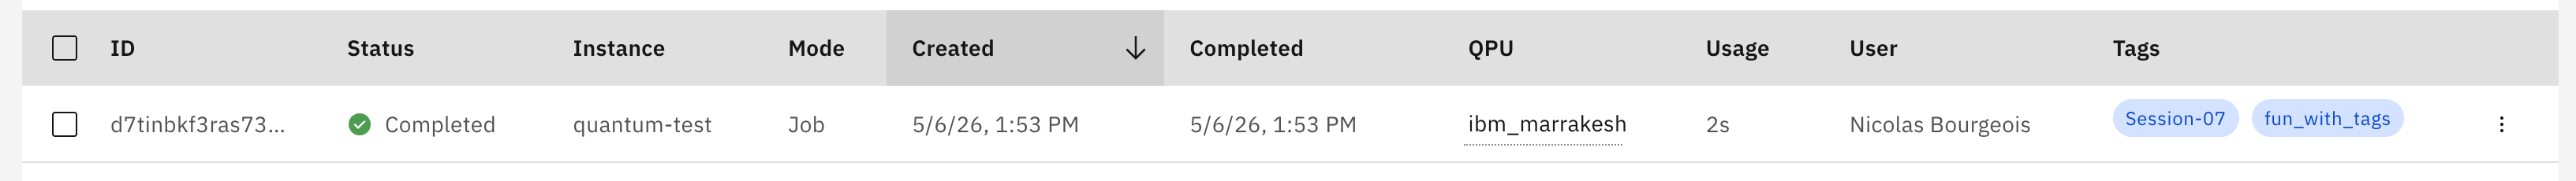

# Import a json and use the data
    


In [65]:
import json
from qiskit_ibm_runtime import RuntimeEncoder

with open("results.json", "w") as file:
    json.dump(result, file, cls=RuntimeEncoder)

In [66]:
from qiskit_ibm_runtime import RuntimeDecoder
with open("results.json", "r") as file:
    result_from_json = json.load(file, cls=RuntimeDecoder)

result_from_json[0].data.meas.get_counts()

{'00': 512, '11': 495, '10': 10, '01': 7}

# Practice questions


---

## Q1 — Runtime Submission

What happens immediately after executing:

```python
job = sampler.run([qc])
```

A. The quantum circuit has fully completed execution  
B. The Runtime service has accepted/submitted the job  
C. Results are automatically downloaded  
D. The job is guaranteed to start running immediately  

<details>
<summary><b>Show Answer</b></summary>

✅ Correct answer: **B**

Explanation:
`sampler.run()` submits the job asynchronously to the Runtime service.
The job may still be queued or waiting for hardware resources.

</details>

---

## Q2 — Retrieve a Previous Job

Which line correctly retrieves a previously submitted Runtime job?

A.
```python
job = service.jobs(job_id)
```

B.
```python
job = service.job(job_id)
```

C.
```python
job = backend.retrieve(job_id)
```

D.
```python
job = runtime.restore(job_id)
```

<details>
<summary><b>Show Answer</b></summary>

✅ Correct answer: **B**

Explanation:
`service.job(job_id)` retrieves a specific remote Runtime job.

`service.jobs()` returns multiple jobs.

</details>

---

## Q3 — Blocking Behavior

Which method is blocking?

A.
```python
job.status()
```

B.
```python
job.job_id()
```

C.
```python
job.result()
```

D.
```python
job.done()
```

<details>
<summary><b>Show Answer</b></summary>

✅ Correct answer: **C**

Explanation:
`job.result()` waits until the Runtime job finishes (or fails).

This is blocking behavior.

</details>

---

## Q4 — Runtime Job States

Which of the following is NOT a typical Runtime job state?

A. `QUEUED`  
B. `RUNNING`  
C. `FINISHED_SUCCESSFULLY`  
D. `ERROR`  

<details>
<summary><b>Show Answer</b></summary>

✅ Correct answer: **C**

Explanation:
Typical Runtime states include:
- `INITIALIZING`
- `QUEUED`
- `RUNNING`
- `DONE`
- `ERROR`
- `CANCELLED`

</details>

---

## Q5 — service.job vs service.jobs

What is the difference between:

```python
service.job(job_id)
```

and

```python
service.jobs()
```

A. One retrieves a single job, the other retrieves multiple jobs  
B. Both are aliases for the same method  
C. One is synchronous, the other asynchronous  
D. One only works on simulators  

<details>
<summary><b>Show Answer</b></summary>

✅ Correct answer: **A**

Explanation:
- `service.job(job_id)` retrieves ONE specific job.
- `service.jobs()` retrieves a collection/list of jobs.

</details>

---

## Q6 — Asynchronous Execution

Why are Runtime jobs considered asynchronous?

A. They automatically parallelize all circuits  
B. The program continues executing after submission  
C. Jobs always run simultaneously on hardware  
D. Results are computed locally first  

<details>
<summary><b>Show Answer</b></summary>

✅ Correct answer: **B**

Explanation:
After job submission, Python execution continues immediately.
The Runtime job executes independently in the background.

</details>

---

## Q7 — Monitoring Jobs

What is the main purpose of:

```python
job.status()
```

A. Submit the job to hardware  
B. Retrieve measurement counts  
C. Query the current execution state  
D. Optimize the transpilation pipeline  

<details>
<summary><b>Show Answer</b></summary>

✅ Correct answer: **C**

Explanation:
`job.status()` checks the current Runtime job state such as:
- `QUEUED`
- `RUNNING`
- `DONE`
- `ERROR`

</details>

---

## Q8 — Remote Persistence

Why can a Runtime job still be retrieved after restarting a notebook?

A. Jobs are cached in local memory  
B. Runtime stores job data remotely  
C. Python automatically serializes jobs  
D. Qiskit stores jobs inside the circuit object  

<details>
<summary><b>Show Answer</b></summary>

✅ Correct answer: **B**

Explanation:
IBM Runtime stores jobs remotely on the service infrastructure,
allowing later retrieval using the job ID.

</details>

---

## Q9 — Python Object Identity

Consider:

```python
job1 = sampler.run([qc])

job2 = service.job(job1.job_id())
```

Which statement is MOST accurate?

A. `job1` and `job2` are guaranteed to be the same Python object  
B. They reference the same remote Runtime job  
C. `job2` is only a copy of local simulator data  
D. `job1` becomes invalid after retrieval  

<details>
<summary><b>Show Answer</b></summary>

✅ Correct answer: **B**

Explanation:
`job1` and `job2` are different local Python objects,
but they refer to the same remote Runtime job.

</details>

---

## Q10 — Practical API Pitfall

Consider:

```python
while not job.done():
    print(job.status())
```

What is a potential issue with this code?

A. It may repeatedly query the Runtime service too aggressively  
B. `job.done()` automatically cancels queued jobs  
C. `job.status()` blocks until completion  
D. The loop cannot execute while a job is queued  

<details>
<summary><b>Show Answer</b></summary>

✅ Correct answer: **A**

Explanation:
This loop may continuously poll the Runtime API extremely rapidly.

In practice, you usually add:

```python
import time
time.sleep(1)
```

inside the loop to avoid excessive API requests.

</details>